In [17]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
import pandas as pd
internal_PDC_VS_MPC_dir = os.getcwd()
internal_March_27_2026_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..'))
print(f'The current working directory is : {internal_PDC_VS_MPC_dir}')
internal_MPC_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The MPC data directory : {internal_MPC_data_dir}')
internal_PD_data_dir = os.path.abspath(os.path.join(internal_March_27_2026_dir, 'March27_2026'))
print(f'The PD data directory : {internal_PD_data_dir}')
internal_VTR_dir = os.path.abspath(os.path.join(internal_PDC_VS_MPC_dir, '..', '..'))
print(f'The VTR directory : {internal_VTR_dir}')
root_dir = os.path.abspath(os.path.join(internal_VTR_dir, '..'))
print(f'The root directory : {root_dir}')
internal_HT_dir = os.path.abspath(os.path.join(root_dir, '8_Hardware', 'Hardware_Testing'))
print(f'The internal HT directory : {internal_HT_dir}')
internal_HT_MPC_dir = os.path.abspath(os.path.join(internal_HT_dir, '2_MPC_Controllers'))
print(f'The internal HT MPC directory : {internal_HT_MPC_dir}')
internal_scripts_dir = os.path.abspath(os.path.join(internal_HT_MPC_dir, 'scripts'))
print(f'The internal scripts directory : {internal_scripts_dir}')
sys.path.append(internal_scripts_dir)
import H_Common_Params as CP

The current working directory is : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The PD data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026
The VTR directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The internal HT directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\8_Hardware\Hardware_Testing
The internal HT MPC directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adapti

In [18]:
internal_PDC_CDP_data_dir = os.path.abspath(os.path.join(internal_PD_data_dir, 'Processed_Data_March27_PD'))
internal_MPC_CDP_data_dir = os.path.abspath(os.path.join(internal_MPC_data_dir, 'Processed_Data_March27_MPC'))
print(f'The PDC data directory : {internal_PDC_CDP_data_dir}')
print(f'The MPC data directory : {internal_MPC_CDP_data_dir}')

The PDC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_PD
The MPC data directory : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\Testing_Using_Radar\March27_2026\Processed_Data_March27_MPC


In [19]:
# Print the names of the files in the PDC and MPC data directories to check if they are the same
print(f'PDC data files : {os.listdir(internal_PDC_CDP_data_dir)}')
print(f'MPC data files : {os.listdir(internal_MPC_CDP_data_dir)}')   
      

PDC data files : ['Data_Mar27_PD_10kph_CS1.csv', 'Data_Mar27_PD_10kph_CS2.csv', 'Data_Mar27_PD_10kph_CS3.csv', 'Data_Mar27_PD_5kph_CS3.csv', 'Data_Mar27_PD_CS1_5kmph.csv', 'Data_Mar27_PD_CS2_5kmph.csv']
MPC data files : ['Data_Mar27_MPC_10kph_CS1.csv', 'Data_Mar27_MPC_10kph_CS2.csv', 'Data_Mar27_MPC_10kph_CS3.csv', 'Data_Mar27_MPC_CS1.csv', 'Data_Mar27_MPC_CS2.csv', 'Data_Mar27_MPC_CS3.csv', 'Data_Mar27_MPC_CS4.csv']


In [20]:
PDC_data_list = []
for i in range(len(os.listdir(internal_PDC_CDP_data_dir))):
    PDC_data_list.append(pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, os.listdir(internal_PDC_CDP_data_dir)[i])))
    
MPC_data_list = []
for i in range(len(os.listdir(internal_MPC_CDP_data_dir))):
    MPC_data_list.append(pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, os.listdir(internal_MPC_CDP_data_dir)[i])))

In [21]:
# Print the column names of the first dataframe in PDC_data_list and MPC_data_list to check if they are the same
print(f'PDC data columns : {PDC_data_list[0].columns}')
print(f'MPC data columns : {MPC_data_list[0].columns}')

PDC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')
MPC data columns : Index(['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)',
       'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)',
       'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph',
       'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean',
       'Ego_Position_clean', 'Obs_Position_clean'],
      dtype='object')


In [22]:
# Want to plot PD vs MPC for the same test case. So i want to select file names i want to compare.
# Assuming that the file names in the PDC and MPC data directories are the same, 
# i can select the file name i want to compare and then plot the data from the selected file name for both PDC and MPC.
PDC_file_name = os.listdir(internal_PDC_CDP_data_dir)[0]    
MPC_file_name = os.listdir(internal_MPC_CDP_data_dir)[0]
print(f'Selected PDC file name : {PDC_file_name}')
print(f'Selected MPC file name : {MPC_file_name}')

Selected PDC file name : Data_Mar27_PD_10kph_CS1.csv
Selected MPC file name : Data_Mar27_MPC_10kph_CS1.csv


PDC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']
MPC columns: ['Ego_Position(m)', 'Ego_Velocity(m/s)', 'Obs_Position(m)', 'Obs_Velocity(m/s)', 'Separation(m)', 'Relative velocity(m/s)', 'Time(s)', 'Time', 'Ego_Velocity_kmph', 'Obs_Velocity_kmph', 'Ego_Velocity_clean', 'Obs_Velocity_clean', 'Separation_clean', 'Ego_Position_clean', 'Obs_Position_clean']


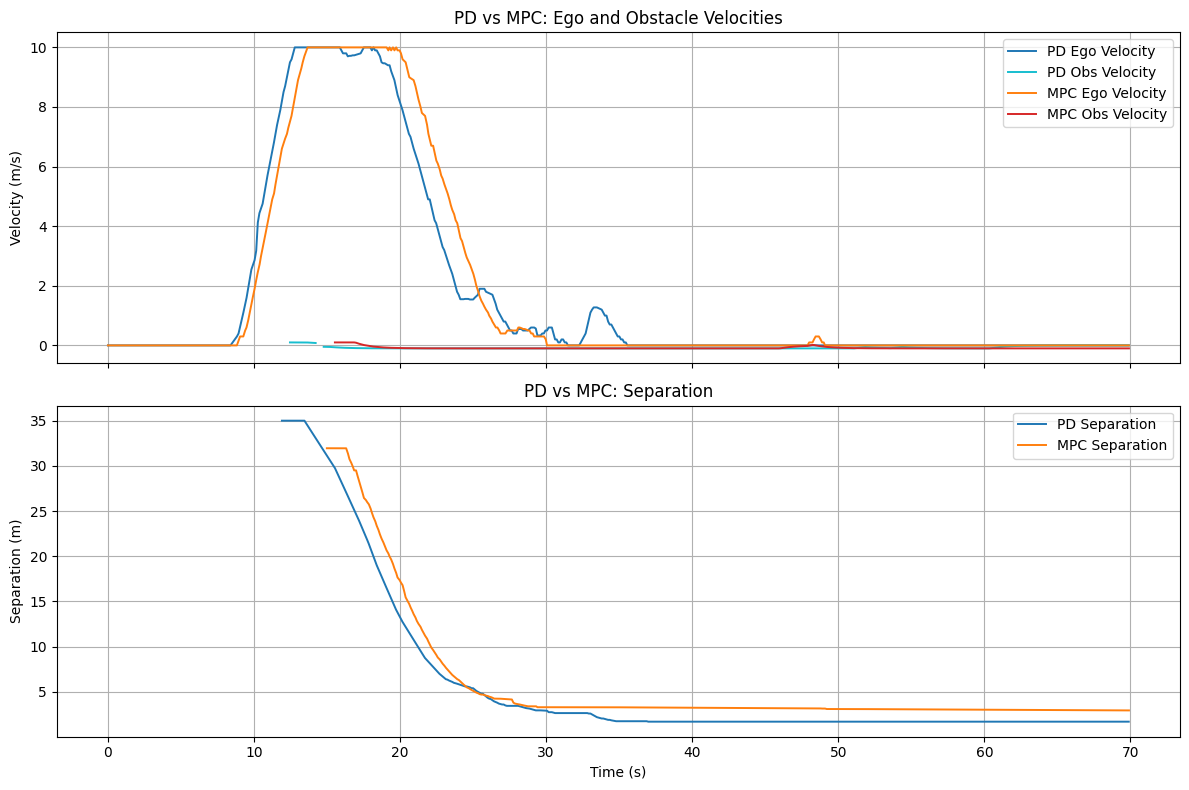

In [23]:
# Plotting the data from the selected file name for both PDC and MPC
# Assuming PDC_data_list and MPC_data_list are loaded, and PDC_file_name & MPC_file_name are selected

pdc_df = pd.read_csv(os.path.join(internal_PDC_CDP_data_dir, PDC_file_name))
mpc_df = pd.read_csv(os.path.join(internal_MPC_CDP_data_dir, MPC_file_name))

print("PDC columns:", pdc_df.columns.tolist())
print("MPC columns:", mpc_df.columns.tolist())

# Use actual column names from your data
x_col = "Time(s)"  # Time in seconds
ego_vel_col = "Ego_Velocity_clean"
obs_vel_col = "Obs_Velocity_clean"
sep_col = "Separation_clean"

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Ego velocity and obstacle velocity for PD and MPC
ax[0].plot(pdc_df[x_col], pdc_df[ego_vel_col], label="PD Ego Velocity", color="tab:blue", linewidth=1.4)
ax[0].plot(pdc_df[x_col], pdc_df[obs_vel_col], label="PD Obs Velocity", color="tab:cyan", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[ego_vel_col], label="MPC Ego Velocity", color="tab:orange", linewidth=1.4)
ax[0].plot(mpc_df[x_col], mpc_df[obs_vel_col], label="MPC Obs Velocity", color="tab:red", linewidth=1.4)
ax[0].set_ylabel("Velocity (m/s)")
ax[0].legend(loc="best")
ax[0].grid(True)
ax[0].set_title("PD vs MPC: Ego and Obstacle Velocities")

# Plot 2: Separation for PD and MPC
ax[1].plot(pdc_df[x_col], pdc_df[sep_col], label="PD Separation", color="tab:blue", linewidth=1.4)
ax[1].plot(mpc_df[x_col], mpc_df[sep_col], label="MPC Separation", color="tab:orange", linewidth=1.4)
ax[1].set_ylabel("Separation (m)")
ax[1].set_xlabel("Time (s)")
ax[1].legend(loc="best")
ax[1].grid(True)
ax[1].set_title("PD vs MPC: Separation")

plt.tight_layout()
plt.show()
   